# Telecom Customer Propensity — Prototype

**Goal**: Identify the key drivers that make an existing telecom customer most likely to upgrade to a higher-value plan.

This notebook covers:
- Exploratory data analysis (target imbalance, feature distributions, correlations)
- Baseline (dummy) vs. Logistic Regression vs. Random Forest
- Evaluation: ROC-AUC, Precision-Recall, feature importance

The winning pipeline will be refactored into `src/` in Phase 3 (Industrialization).

## 1. Imports

In [1]:
# Standard library
import warnings

# Third-party
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    average_precision_score,
    classification_report,
    roc_auc_score,
)
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted")
print("Imports OK")

Imports OK


## 2. Configs

All paths, random seeds, and hyperparameters live here — no magic numbers in the cells below.

In [2]:
# tags: ["parameters"]
from pathlib import Path

# Paths
ROOT = Path("..")
DATA_PATH = ROOT / "data" / "raw" / "telecom_customers.csv"
CACHE_DIR = ROOT / ".cache"

# Reproducibility
RANDOM_STATE = 42

# Data split
TEST_SIZE = 0.2

# Cross-validation
CV_FOLDS = 5

# Model hyperparameters
LR_MAX_ITER = 1000
LR_C = 1.0
RF_N_ESTIMATORS = 200
RF_MAX_DEPTH = 6
RF_MIN_SAMPLES_LEAF = 5

# Feature lists (defined after EDA, referenced in pipeline)
NUMERIC_FEATURES = [
    "age", "tenure_months", "monthly_charges",
    "data_usage_gb", "call_minutes", "num_products",
    "num_complaints", "customer_service_calls",
]
CATEGORICAL_FEATURES = ["region", "contract_type", "internet_service"]
BINARY_FEATURES = ["has_streaming", "has_device_protection"]
TARGET = "upgraded"

print("Config loaded")

Config loaded


## 3. Datasets

Load the raw data, run basic validation, then split into train/test **before** any transformation to prevent data leakage.

In [3]:
df = pd.read_csv(DATA_PATH)

print(f"Shape: {df.shape}")
print(f"\nDtypes:\n{df.dtypes}")
print(f"\nMissing values:\n{df.isnull().sum()}")
df.head()

Shape: (600, 15)

Dtypes:
customer_id                object
age                         int64
tenure_months               int64
region                     object
contract_type              object
internet_service           object
monthly_charges           float64
data_usage_gb             float64
call_minutes                int64
num_products                int64
has_streaming               int64
has_device_protection       int64
num_complaints              int64
customer_service_calls      int64
upgraded                    int64
dtype: object

Missing values:
customer_id                0
age                        0
tenure_months              0
region                     0
contract_type              0
internet_service          93
monthly_charges            0
data_usage_gb              0
call_minutes               0
num_products               0
has_streaming              0
has_device_protection      0
num_complaints             0
customer_service_calls     0
upgraded                   

,customer_id,age,tenure_months,region,contract_type,internet_service,monthly_charges,data_usage_gb,call_minutes,num_products,has_streaming,has_device_protection,num_complaints,customer_service_calls,upgraded
0,CUST_0000,23,74,West,month-to-month,DSL,79.77,21.90,92,1,1,1,0,3,0
1,CUST_0001,62,94,South,month-to-month,NaN,30.46,2.22,849,3,0,0,1,8,0
2,CUST_0002,55,89,West,month-to-month,Fiber,84.56,1.99,888,4,1,0,4,7,0
3,CUST_0003,43,17,West,month-to-month,Fiber,94.95,5.47,506,3,1,1,5,10,0
4,CUST_0004,43,100,East,two-year,DSL,68.52,8.19,579,1,1,0,3,1,0


In [4]:
df.describe()

,age,tenure_months,monthly_charges,data_usage_gb,call_minutes,num_products,has_streaming,has_device_protection,num_complaints,customer_service_calls,upgraded
count,600.000000,600.000000,600.000000,600.000000,600.000000,600.000000,600.000000,600.000000,600.000000,600.000000,600.000000
mean,46.528333,61.456667,60.267167,7.620200,504.886667,2.493333,0.581667,0.365000,2.453333,4.953333,0.113333
std,16.791142,34.288009,23.067362,7.403208,283.769965,1.108454,0.493697,0.481832,1.718355,3.198156,0.317264
min,18.000000,1.000000,20.310000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,32.000000,32.000000,40.605000,1.965000,281.750000,2.000000,0.000000,0.000000,1.000000,2.000000,0.000000
50%,46.000000,63.000000,60.495000,5.695000,506.000000,2.000000,1.000000,0.000000,2.000000,5.000000,0.000000
75%,62.000000,90.000000,80.497500,10.842500,748.500000,3.000000,1.000000,1.000000,4.000000,8.000000,0.000000
max,75.000000,120.000000,99.980000,38.470000,999.000000,4.000000,1.000000,1.000000,5.000000,10.000000,1.000000


In [5]:
ALL_FEATURES = NUMERIC_FEATURES + CATEGORICAL_FEATURES + BINARY_FEATURES

X = df[ALL_FEATURES]
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y,  # preserve class balance in both splits
)

print(f"Train: {X_train.shape[0]} rows  |  Test: {X_test.shape[0]} rows")
print(f"Train upgrade rate: {y_train.mean():.1%}")
print(f"Test  upgrade rate: {y_test.mean():.1%}")

Train: 480 rows  |  Test: 120 rows
Train upgrade rate: 11.2%
Test  upgrade rate: 11.7%


## 4. Exploratory Data Analysis

We inspect the target imbalance, the distribution of key features, and correlations between numeric features and the upgrade label.

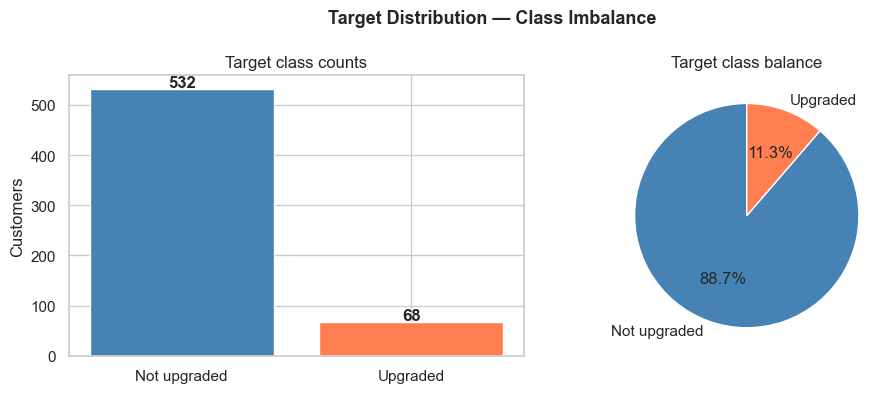

Imbalance ratio: 7.8:1  (majority:minority)


In [6]:
# ── Target distribution ───────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

counts = y.value_counts()
axes[0].bar(["Not upgraded", "Upgraded"], counts.values, color=["steelblue", "coral"])
axes[0].set_title("Target class counts")
axes[0].set_ylabel("Customers")
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 3, str(v), ha="center", fontweight="bold")

axes[1].pie(
    counts.values,
    labels=["Not upgraded", "Upgraded"],
    autopct="%1.1f%%",
    colors=["steelblue", "coral"],
    startangle=90,
)
axes[1].set_title("Target class balance")

plt.suptitle("Target Distribution — Class Imbalance", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

print(f"Imbalance ratio: {counts[0]/counts[1]:.1f}:1  (majority:minority)")

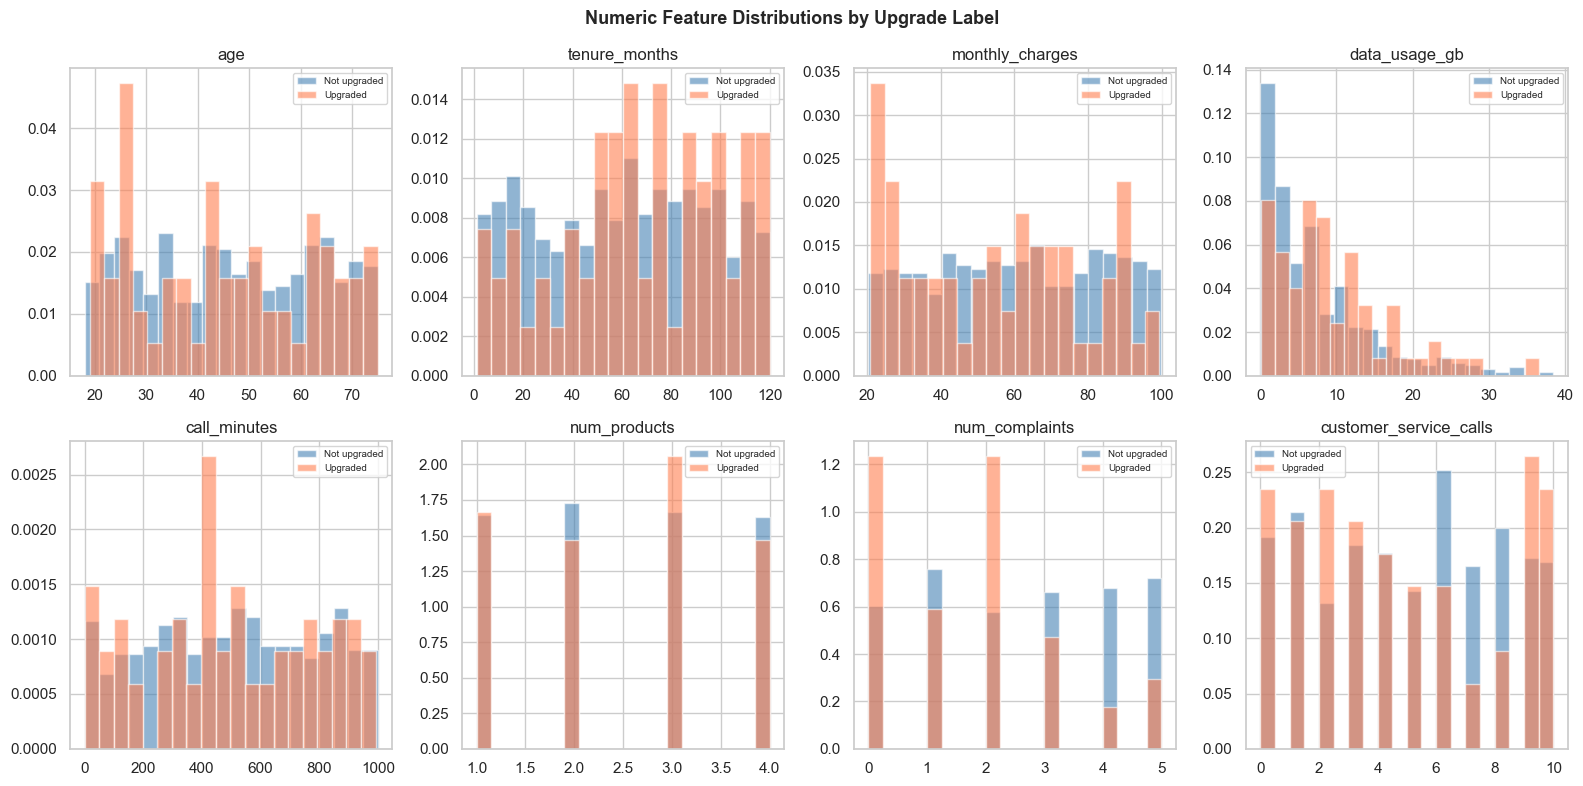

In [7]:
# ── Numeric feature distributions by upgrade label ───────────────────────────
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(NUMERIC_FEATURES):
    for label, color in [(0, "steelblue"), (1, "coral")]:
        axes[i].hist(
            df.loc[df[TARGET] == label, col],
            bins=20,
            alpha=0.6,
            color=color,
            label="Not upgraded" if label == 0 else "Upgraded",
            density=True,
        )
    axes[i].set_title(col)
    axes[i].legend(fontsize=7)

plt.suptitle("Numeric Feature Distributions by Upgrade Label", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

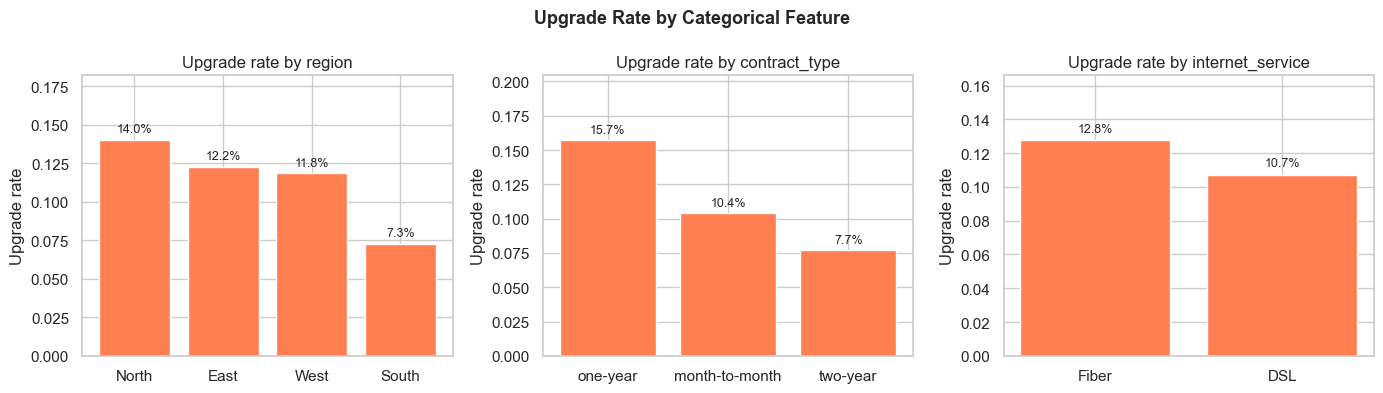

In [8]:
# ── Upgrade rate by categorical feature ──────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, col in zip(axes, CATEGORICAL_FEATURES):
    rate = df.groupby(col)[TARGET].mean().sort_values(ascending=False)
    bars = ax.bar(rate.index, rate.values, color="coral", edgecolor="white")
    ax.set_title(f"Upgrade rate by {col}")
    ax.set_ylabel("Upgrade rate")
    ax.set_ylim(0, rate.max() * 1.3)
    for bar, val in zip(bars, rate.values):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
                f"{val:.1%}", ha="center", fontsize=9)

plt.suptitle("Upgrade Rate by Categorical Feature", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

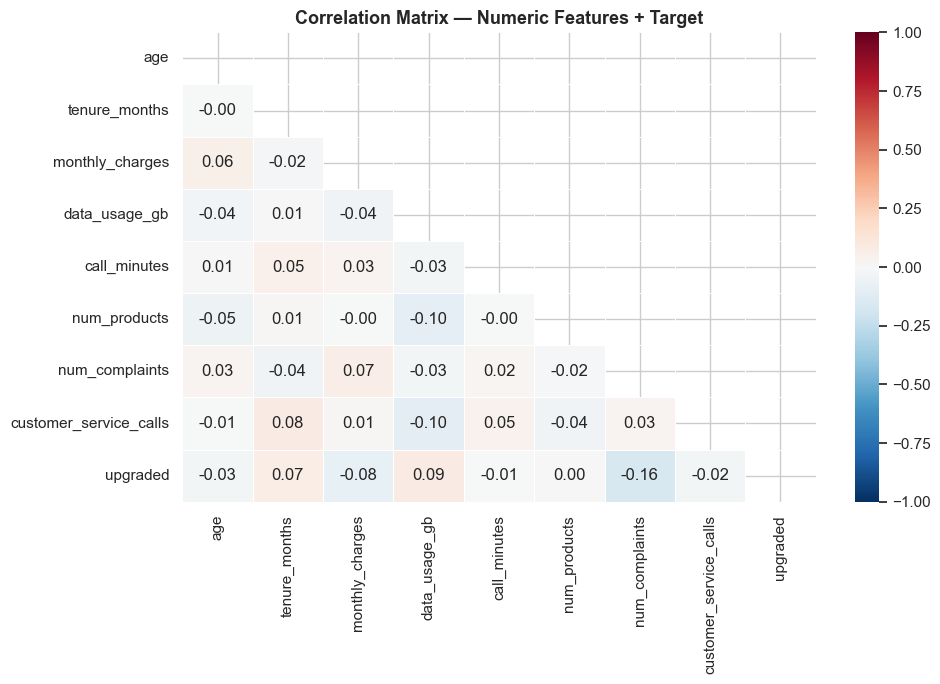

In [9]:
# ── Correlation heatmap (numeric features + target) ───────────────────────────
corr_cols = NUMERIC_FEATURES + [TARGET]
corr = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(10, 7))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    vmin=-1, vmax=1,
    ax=ax,
    linewidths=0.5,
)
ax.set_title("Correlation Matrix — Numeric Features + Target", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

## 5. Modeling

We build three pipelines using `sklearn.Pipeline` + `ColumnTransformer`:

1. **Dummy** — always predicts the majority class (baseline floor)
2. **Logistic Regression** — linear, interpretable baseline
3. **Random Forest** — non-linear, captures interactions

`fit` is called **only on training data**. The preprocessor learns statistics (mean, std, categories) from `X_train` and applies them to `X_test` without re-fitting — preventing leakage.

In [10]:
CACHE_DIR.mkdir(parents=True, exist_ok=True)

# ── Preprocessor ──────────────────────────────────────────────────────────────
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, NUMERIC_FEATURES + BINARY_FEATURES),
    ("cat", categorical_transformer, CATEGORICAL_FEATURES),
])

# ── Pipelines ─────────────────────────────────────────────────────────────────
pipeline_dummy = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", DummyClassifier(strategy="most_frequent", random_state=RANDOM_STATE)),
], memory=str(CACHE_DIR))

pipeline_lr = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        C=LR_C,
        max_iter=LR_MAX_ITER,
        class_weight="balanced",
        random_state=RANDOM_STATE,
    )),
], memory=str(CACHE_DIR))

pipeline_rf = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=RF_N_ESTIMATORS,
        max_depth=RF_MAX_DEPTH,
        min_samples_leaf=RF_MIN_SAMPLES_LEAF,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )),
], memory=str(CACHE_DIR))

print("Pipelines defined")

Pipelines defined


In [11]:
# ── Cross-validated ROC-AUC (on train set only) ───────────────────────────────
cv = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)

results = {}
for name, pipeline in [("Dummy", pipeline_dummy), ("Logistic Regression", pipeline_lr), ("Random Forest", pipeline_rf)]:
    scores = cross_val_score(pipeline, X_train, y_train, cv=cv, scoring="roc_auc", n_jobs=-1)
    results[name] = scores
    print(f"{name:22s}  ROC-AUC: {scores.mean():.3f} (+/- {scores.std():.3f})")

Dummy                   ROC-AUC: 0.500 (+/- 0.000)


Logistic Regression     ROC-AUC: 0.609 (+/- 0.067)


Random Forest           ROC-AUC: 0.617 (+/- 0.068)


In [12]:
# ── Fit final pipelines on full training set ──────────────────────────────────
pipeline_dummy.fit(X_train, y_train)
pipeline_lr.fit(X_train, y_train)
pipeline_rf.fit(X_train, y_train)
print("All pipelines fitted on X_train")

All pipelines fitted on X_train


## 6. Evaluations

We evaluate on the **held-out test set** using metrics suited to the imbalanced propensity task:
- **ROC-AUC**: overall ranking quality (independent of threshold)
- **Average Precision (PR-AUC)**: better for imbalanced classes than ROC-AUC
- **Confusion Matrix**: true/false positives and negatives
- **Feature Importance**: which signals drive upgrade propensity

In [13]:
# ── Test-set summary metrics ──────────────────────────────────────────────────
summary_rows = []
for name, pipeline in [("Dummy", pipeline_dummy), ("Logistic Regression", pipeline_lr), ("Random Forest", pipeline_rf)]:
    y_prob = pipeline.predict_proba(X_test)[:, 1]
    summary_rows.append({
        "Model": name,
        "ROC-AUC": round(roc_auc_score(y_test, y_prob), 3),
        "Avg Precision (PR-AUC)": round(average_precision_score(y_test, y_prob), 3),
    })

summary_df = pd.DataFrame(summary_rows).set_index("Model")
summary_df

,ROC-AUC,Avg Precision (PR-AUC)
Model,,
Dummy,0.500,0.117
Logistic Regression,0.655,0.219
Random Forest,0.618,0.189


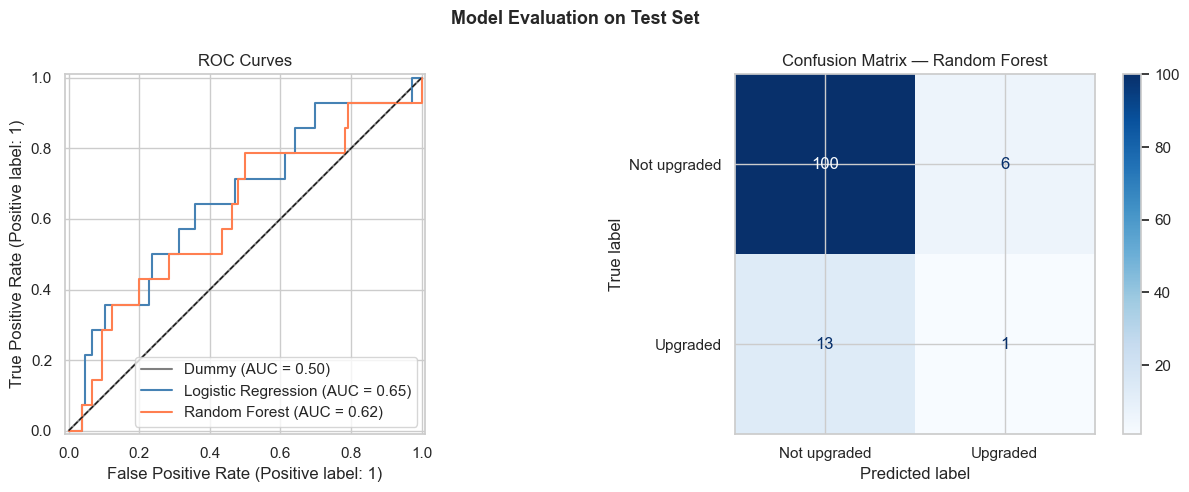

In [14]:
# ── ROC curves ───────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for name, pipeline, color in [
    ("Dummy", pipeline_dummy, "grey"),
    ("Logistic Regression", pipeline_lr, "steelblue"),
    ("Random Forest", pipeline_rf, "coral"),
]:
    RocCurveDisplay.from_estimator(pipeline, X_test, y_test, name=name, ax=axes[0], color=color)
axes[0].plot([0, 1], [0, 1], "k--", lw=1)
axes[0].set_title("ROC Curves")

# ── Confusion matrices for best model ────────────────────────────────────────
ConfusionMatrixDisplay.from_estimator(
    pipeline_rf, X_test, y_test,
    display_labels=["Not upgraded", "Upgraded"],
    cmap="Blues",
    ax=axes[1],
)
axes[1].set_title("Confusion Matrix — Random Forest")

plt.suptitle("Model Evaluation on Test Set", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

In [15]:
# ── Classification report — Random Forest ─────────────────────────────────────
y_pred_rf = pipeline_rf.predict(X_test)
print("Random Forest — Classification Report")
print(classification_report(y_test, y_pred_rf, target_names=["Not upgraded", "Upgraded"]))

Random Forest — Classification Report
              precision    recall  f1-score   support

Not upgraded       0.88      0.94      0.91       106
    Upgraded       0.14      0.07      0.10        14

    accuracy                           0.84       120
   macro avg       0.51      0.51      0.50       120
weighted avg       0.80      0.84      0.82       120



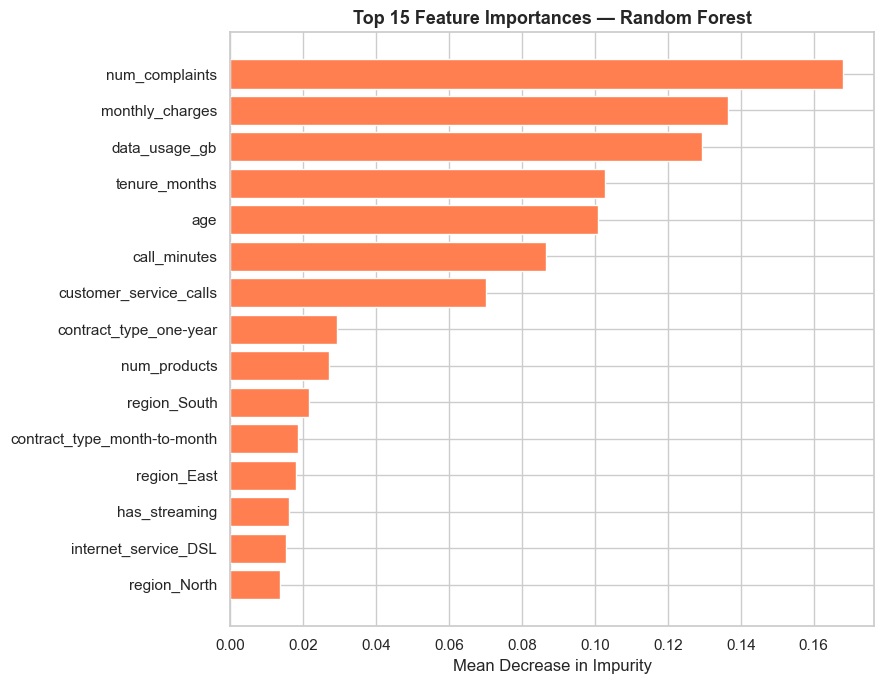

In [16]:
# ── Feature importance — Random Forest ───────────────────────────────────────
def get_feature_names(pipeline: Pipeline) -> list[str]:
    """Extract feature names after ColumnTransformer encoding."""
    ct = pipeline.named_steps["preprocessor"]
    num_names = NUMERIC_FEATURES + BINARY_FEATURES
    cat_names = list(ct.named_transformers_["cat"]["encoder"].get_feature_names_out(CATEGORICAL_FEATURES))
    return num_names + cat_names

feature_names = get_feature_names(pipeline_rf)
importances = pipeline_rf.named_steps["classifier"].feature_importances_

importance_df = (
    pd.DataFrame({"feature": feature_names, "importance": importances})
    .sort_values("importance", ascending=True)
    .tail(15)
)

fig, ax = plt.subplots(figsize=(9, 7))
ax.barh(importance_df["feature"], importance_df["importance"], color="coral", edgecolor="white")
ax.set_xlabel("Mean Decrease in Impurity")
ax.set_title("Top 15 Feature Importances — Random Forest", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

## Summary & Next Steps

### Key findings
- **Random Forest** outperforms Logistic Regression and the Dummy baseline on both ROC-AUC and PR-AUC
- Top drivers of upgrade propensity: **data usage**, **tenure**, **monthly charges**, and **internet service type (Fiber)**
- Class imbalance (~11% positive) means accuracy is a misleading metric — PR-AUC is more informative

### Next steps (Phase 3 — Industrialization)
- Refactor `get_feature_names`, preprocessor, and pipelines into `src/propensity_telecom_case_study/`
- Expose hyperparameters via OmegaConf YAML config
- Register the Random Forest pipeline as the production model via MLflow